# Supply Chain & Demand Intelligence Platform
## Exploratory Data Analysis

This notebook explores the cleaned supply-chain dataset to identify
patterns, relationships, operational issues, and business opportunities.

The analysis is structured around four management questions:

1. What is happening?
2. Why is it happening?
3. What is likely to happen next?
4. What decisions should management consider?

The analysis focuses on:

- Revenue and profitability
- Customer and order performance
- Product and category performance
- Geographic performance
- Logistics and delivery performance
- Time-based trends
- Demand patterns
- Potential outliers and unusual behavior

### Analytical Principle

Every analysis should answer a meaningful business question.
Charts are used to support interpretation rather than as an end in themselves.

### Dataset Grain

The cleaned dataset is at the **order-item level**.

Therefore:

- Row count does not represent the number of orders.
- Order-level metrics should use unique `Order Id`.
- Customer-level metrics should use unique `Customer Id`.
- Order-item metrics should use unique `Order Item Id`.

## 1. Setup

We begin by loading the cleaned dataset and importing the libraries
required for exploratory analysis.

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [4]:
file_path = "../data/processed/supply_chain_cleaned.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["order date (DateOrders)", "shipping date (DateOrders)"]
)

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Id,Customer Segment,Customer State,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,order date (DateOrders),Order Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Image,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,2018-01-31 22:56:00,77202,13.11,0.04,180517,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,2018-01-13 12:27:00,75939,16.39,0.05,179254,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,"95,125.00",2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,2018-01-13 12:06:00,75938,18.03,0.06,179253,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,19490,Home Office,CA,"90,027.00",2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,2018-01-13 11:45:00,75937,22.94,0.07,179252,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,19489,Corporate,PR,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,2018-01-13 11:24:00,75936,29.50,0.09,179251,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


## Date Formatting

Date columns are explicitly converted into datetime format to enable time-based analysis.

This allows analysis of:

- Sales trends over time
- Monthly performance
- Seasonal patterns
- Delivery timelines

In [8]:
date_columns = [
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

df[date_columns].dtypes

order date (DateOrders)       datetime64[us]
shipping date (DateOrders)    datetime64[us]
dtype: object

In [5]:
print("Dataset shape:", df.shape)

print("\nUnique entities:")
print("Orders:", df["Order Id"].nunique())
print("Customers:", df["Customer Id"].nunique())
print("Order Items:", df["Order Item Id"].nunique())
print("Products:", df["Product Name"].nunique())
print("Categories:", df["Category Name"].nunique())

Dataset shape: (180519, 40)

Unique entities:
Orders: 65752
Customers: 20652
Order Items: 180519
Products: 118
Categories: 50


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  str           
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Sales per customer             180519 non-null  float64       
 4   Delivery Status                180519 non-null  str           
 5   Late_delivery_risk             180519 non-null  int64         
 6   Category Id                    180519 non-null  int64         
 7   Category Name                  180519 non-null  str           
 8   Customer City                  180519 non-null  str           
 9   Customer Country               180519 non-null  str           
 10  Customer Id                    180519 non-null  int64         
 11  Customer Se

## 3. Revenue & Profitability

This section evaluates the financial performance of the supply chain
business using revenue, discounts, profitability, and order-level metrics.

The analysis distinguishes between gross sales, net sales, and the
source-provided profit measure.

Key questions:

- How much revenue does the business generate?
- How profitable is that revenue?
- How much value is being given away through discounts?
- What is the average value of an order?
- Does strong sales performance translate into strong profitability?

In [7]:
total_gross_sales = df["Sales"].sum()
total_net_sales = df["Order Item Total"].sum()
total_discount = df["Order Item Discount"].sum()
total_profit = df["Order Profit Per Order"].sum()

total_orders = df["Order Id"].nunique()
total_customers = df["Customer Id"].nunique()
total_order_items = df["Order Item Id"].nunique()
total_units = df["Order Item Quantity"].sum()

profit_margin = total_profit / total_net_sales
average_discount_rate = df["Order Item Discount Rate"].mean()

order_values = df.groupby("Order Id")["Order Item Total"].sum()
average_order_value = order_values.mean()

print(f"Gross Sales:        ${total_gross_sales:,.2f}")
print(f"Net Sales:          ${total_net_sales:,.2f}")
print(f"Total Discount:     ${total_discount:,.2f}")
print(f"Total Profit:       ${total_profit:,.2f}")
print(f"Profit Margin:      {profit_margin:.2%}")
print(f"Average Discount:   {average_discount_rate:.2%}")
print(f"Orders:             {total_orders:,}")
print(f"Customers:          {total_customers:,}")
print(f"Order Items:        {total_order_items:,}")
print(f"Units Sold:         {total_units:,}")
print(f"Average Order Value:${average_order_value:,.2f}")

Gross Sales:        $36,784,735.01
Net Sales:          $33,054,402.38
Total Discount:     $3,730,378.40
Total Profit:       $3,966,902.97
Profit Margin:      12.00%
Average Discount:   10.17%
Orders:             65,752
Customers:          20,652
Order Items:        180,519
Units Sold:         384,079
Average Order Value:$502.71


In [8]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Gross Sales",
        "Net Sales",
        "Total Discount",
        "Total Profit",
        "Profit Margin",
        "Average Discount Rate",
        "Orders",
        "Customers",
        "Order Items",
        "Units Sold",
        "Average Order Value"
    ],
    "Value": [
        total_gross_sales,
        total_net_sales,
        total_discount,
        total_profit,
        profit_margin,
        average_discount_rate,
        total_orders,
        total_customers,
        total_order_items,
        total_units,
        average_order_value
    ]
})

kpi_summary

,KPI,Value
0,Gross Sales,"36,784,735.01"
1,Net Sales,"33,054,402.38"
2,Total Discount,"3,730,378.40"
3,Total Profit,"3,966,902.97"
4,Profit Margin,0.12
5,Average Discount Rate,0.10
6,Orders,"65,752.00"
7,Customers,"20,652.00"
8,Order Items,"180,519.00"
9,Units Sold,"384,079.00"


### 3.1 Category Revenue & Profitability

The overall business KPIs provide a high-level view, but they do not
show where revenue and profit are being generated.

This analysis compares product categories using:

- Gross sales
- Net sales
- Discounts
- Profit
- Profit margin
- Units sold

The objective is to identify categories that generate strong financial
performance as well as categories where high sales may not translate
into strong profitability.

In [9]:
category_performance = (
    df.groupby("Category Name")
      .agg(
          Gross_Sales=("Sales", "sum"),
          Net_Sales=("Order Item Total", "sum"),
          Discount=("Order Item Discount", "sum"),
          Profit=("Order Profit Per Order", "sum"),
          Units_Sold=("Order Item Quantity", "sum"),
          Order_Items=("Order Item Id", "nunique")
      )
      .reset_index()
)

category_performance["Profit_Margin"] = (
    category_performance["Profit"] /
    category_performance["Net_Sales"]
)

category_performance["Discount_Rate"] = (
    category_performance["Discount"] /
    category_performance["Gross_Sales"]
)

category_performance.sort_values(
    "Net_Sales",
    ascending=False
)

,Category Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
18,Fishing,"6,929,653.69","6,226,935.29","702,728.00","756,220.77",17325,17325,0.12,0.10
12,Cleats,"4,431,942.78","3,982,856.50","449,091.67","494,636.92",73734,24551,0.12,0.10
9,Camping & Hiking,"4,118,425.57","3,700,783.63","417,649.50","427,455.57",13729,13729,0.12,0.10
10,Cardio Equipment,"3,694,843.20","3,320,250.70","374,595.19","383,011.10",37587,12487,0.12,0.10
47,Women's Apparel,"3,147,800.00","2,828,708.50","319,091.50","350,421.03",62956,21035,0.12,0.10
46,Water Sports,"3,113,844.68","2,798,044.18","315,800.50","325,146.96",15540,15540,0.12,0.10
34,Men's Footwear,"2,891,757.66","2,598,494.42","293,263.10","311,902.82",22246,22246,0.12,0.10
30,Indoor/Outdoor Games,"2,888,993.91","2,596,454.02","292,550.63","318,451.43",57803,19298,0.12,0.10
38,Shop By Sport,"1,309,522.04","1,177,185.63","132,338.73","129,813.96",32726,10984,0.11,0.10
13,Computers,"663,000.00","595,395.00","67,605.00","69,656.81",442,442,0.12,0.10


In [10]:
category_performance.sort_values(
    "Profit",
    ascending=False
).head(10)

,Category Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
18,Fishing,"6,929,653.69","6,226,935.29","702,728.00","756,220.77",17325,17325,0.12,0.10
12,Cleats,"4,431,942.78","3,982,856.50","449,091.67","494,636.92",73734,24551,0.12,0.10
9,Camping & Hiking,"4,118,425.57","3,700,783.63","417,649.50","427,455.57",13729,13729,0.12,0.10
10,Cardio Equipment,"3,694,843.20","3,320,250.70","374,595.19","383,011.10",37587,12487,0.12,0.10
47,Women's Apparel,"3,147,800.00","2,828,708.50","319,091.50","350,421.03",62956,21035,0.12,0.10
46,Water Sports,"3,113,844.68","2,798,044.18","315,800.50","325,146.96",15540,15540,0.12,0.10
30,Indoor/Outdoor Games,"2,888,993.91","2,596,454.02","292,550.63","318,451.43",57803,19298,0.12,0.10
34,Men's Footwear,"2,891,757.66","2,598,494.42","293,263.10","311,902.82",22246,22246,0.12,0.10
38,Shop By Sport,"1,309,522.04","1,177,185.63","132,338.73","129,813.96",32726,10984,0.11,0.10
13,Computers,"663,000.00","595,395.00","67,605.00","69,656.81",442,442,0.12,0.10


In [11]:
category_performance.sort_values(
    "Profit",
    ascending=True
).head(10)

,Category Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
41,Strength Training,"54,895.53","48,813.84","6,081.72",332.31,111,111,0.01,0.11
7,CDs,"3,059.59","2,750.03",309.56,383.85,271,271,0.14,0.10
1,As Seen on TV!,"20,597.94","18,519.61","2,078.37",714.43,206,68,0.04,0.10
5,Books,"12,587.40","11,303.42","1,283.98",883.01,405,405,0.08,0.10
43,Toys,"6,104.66","5,485.68",619.27,900.71,529,529,0.16,0.10
2,Baby,"12,229.56","10,957.40","1,272.16","1,525.03",207,207,0.14,0.10
23,Golf Bags & Carts,"10,369.39","9,403.79",965.60,"1,810.07",61,61,0.19,0.09
4,Basketball,"27,099.33","24,705.33","2,394.00","1,845.67",67,67,0.07,0.09
33,Men's Clothing,"43,856.80","39,365.71","4,491.21","2,006.04",208,208,0.05,0.10
45,Video Games,"33,310.50","29,919.20","3,392.69","2,717.52",838,838,0.09,0.10


In [12]:
category_performance.sort_values(
    "Profit_Margin",
    ascending=False
)

,Category Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
23,Golf Bags & Carts,"10,369.39","9,403.79",965.60,"1,810.07",61,61,0.19,0.09
19,Fitness Accessories,"35,601.44","31,751.36","3,850.16","5,258.39",856,309,0.17,0.11
43,Toys,"6,104.66","5,485.68",619.27,900.71,529,529,0.16,0.10
39,Soccer,"26,477.05","23,909.95","2,567.12","3,901.95",295,138,0.16,0.10
48,Women's Clothing,"140,283.00","126,006.93","14,276.44","19,102.85",650,650,0.15,0.10
3,Baseball & Softball,"94,057.15","84,367.27","9,689.99","12,762.13",1785,632,0.15,0.10
20,Garden,"257,768.73","231,765.46","26,003.52","33,443.01",484,484,0.14,0.10
42,Tennis & Racquet,"44,585.09","40,077.81","4,507.39","5,747.98",991,328,0.14,0.10
36,Music,"113,122.10","101,687.29","11,435.05","14,436.32",434,434,0.14,0.10
7,CDs,"3,059.59","2,750.03",309.56,383.85,271,271,0.14,0.10


### 3.2 Revenue Scale vs Profitability

A category's absolute revenue and profitability should be evaluated
together.

A high-revenue category with weak margins may require a different
management response than a low-revenue category with strong margins.

This analysis therefore compares:

- Net sales
- Profit margin
- Absolute profit

The objective is to identify strong performers, high-revenue/low-margin
categories, and potentially attractive but small categories.

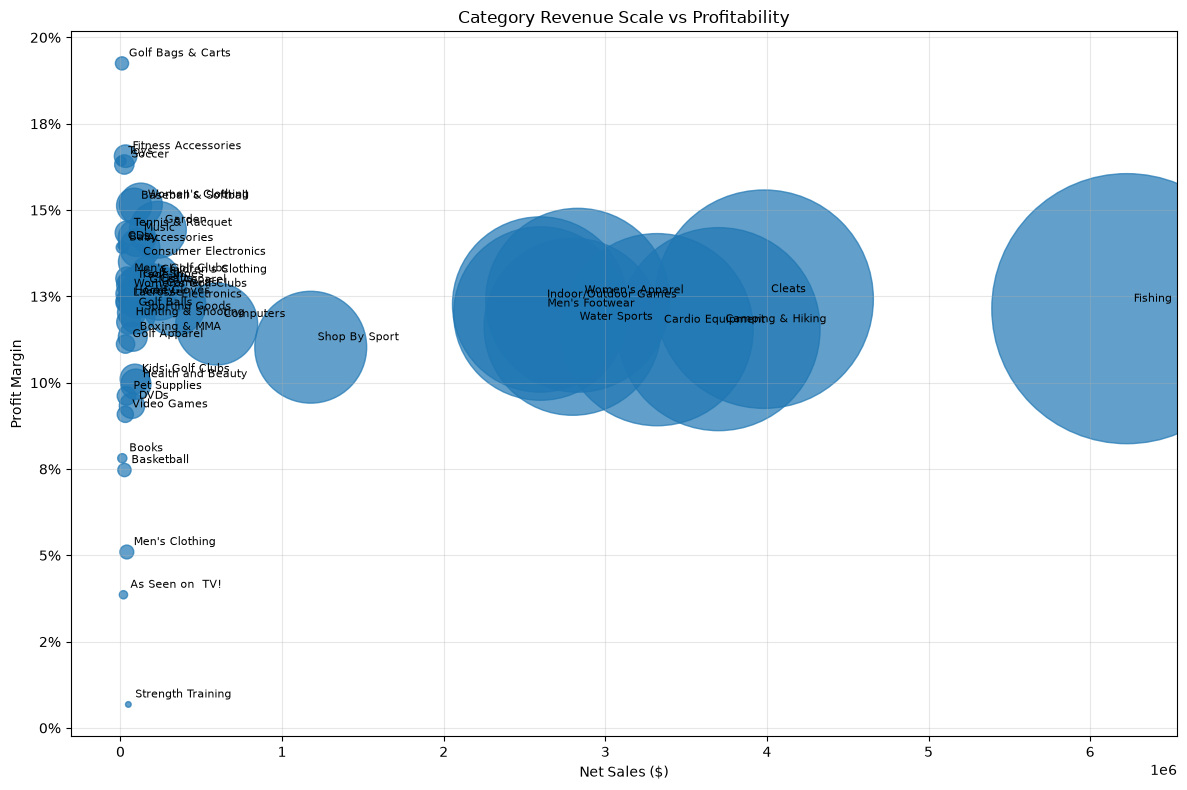

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    category_performance["Net_Sales"],
    category_performance["Profit_Margin"],
    s=category_performance["Profit"] / 20,
    alpha=0.7
)

for _, row in category_performance.iterrows():
    ax.annotate(
        row["Category Name"],
        (row["Net_Sales"], row["Profit_Margin"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title("Category Revenue Scale vs Profitability")
ax.set_xlabel("Net Sales ($)")
ax.set_ylabel("Profit Margin")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

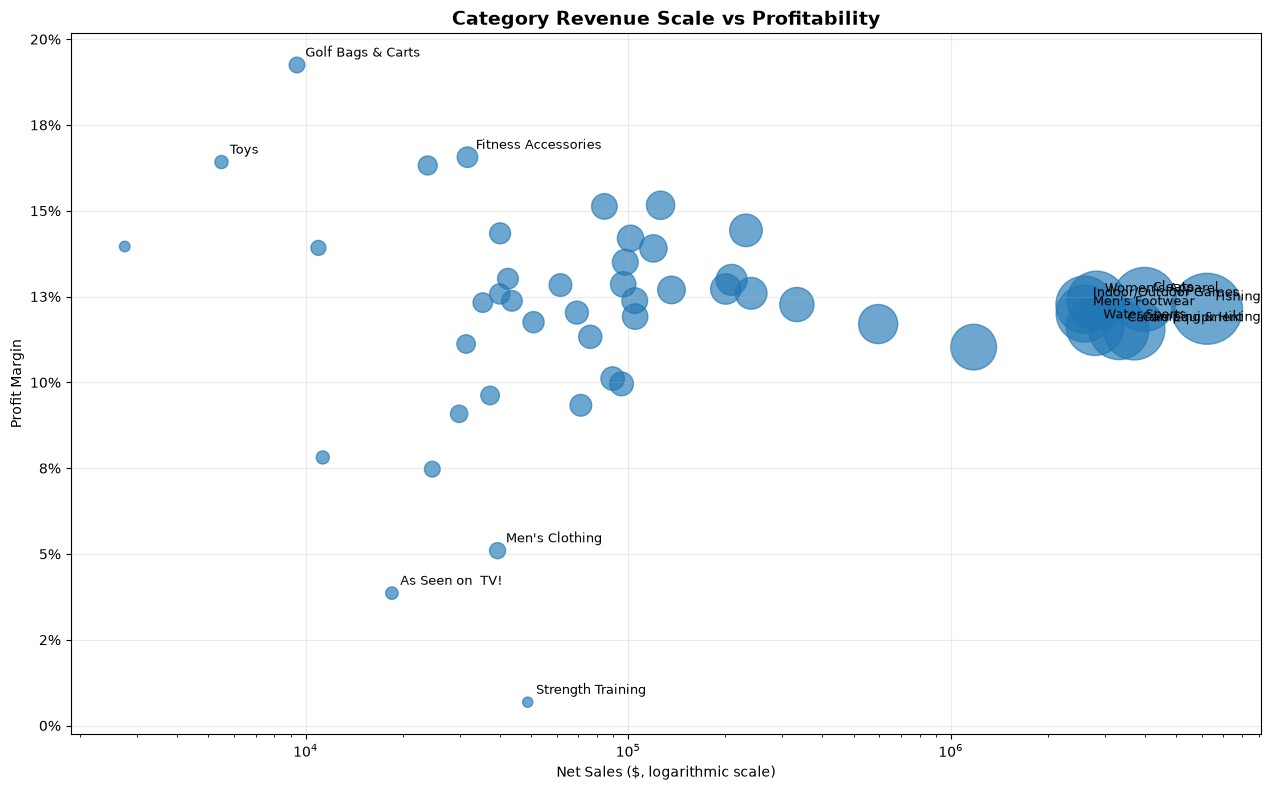

In [14]:
fig, ax = plt.subplots(figsize=(13, 8))

bubble_sizes = np.sqrt(category_performance["Profit"]) * 3

ax.scatter(
    category_performance["Net_Sales"],
    category_performance["Profit_Margin"],
    s=bubble_sizes,
    alpha=0.65
)

# Label only strategically important categories
important_categories = pd.concat([
    category_performance.nlargest(8, "Net_Sales"),
    category_performance.nsmallest(3, "Profit_Margin"),
    category_performance.nlargest(3, "Profit_Margin")
]).drop_duplicates()

for _, row in important_categories.iterrows():
    ax.annotate(
        row["Category Name"],
        (row["Net_Sales"], row["Profit_Margin"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xscale("log")

ax.set_title(
    "Category Revenue Scale vs Profitability",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Net Sales ($, logarithmic scale)")
ax.set_ylabel("Profit Margin")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 3.3 Discounting vs Profitability

Discounting can increase sales volume but may reduce profitability.

This analysis investigates whether differences in category discount rates
are associated with differences in profit margins.

The objective is not to assume that discounts cause lower profitability,
but to determine whether a relationship exists in the observed data.

In [15]:
discount_profitability = category_performance[
    [
        "Category Name",
        "Discount_Rate",
        "Profit_Margin",
        "Net_Sales",
        "Profit"
    ]
].copy()

discount_profitability.sort_values(
    "Discount_Rate",
    ascending=False
)

,Category Name,Discount_Rate,Profit_Margin,Net_Sales,Profit
41,Strength Training,0.11,0.01,"48,813.84",332.31
19,Fitness Accessories,0.11,0.17,"31,751.36","5,258.39"
26,Golf Shoes,0.11,0.13,"96,506.47","12,406.07"
29,Hunting & Shooting,0.11,0.12,"50,878.91","5,980.00"
6,Boxing & MMA,0.10,0.11,"76,286.72","8,641.37"
0,Accessories,0.10,0.14,"119,712.55","16,643.52"
2,Baby,0.10,0.14,"10,957.40","1,525.03"
3,Baseball & Softball,0.10,0.15,"84,367.27","12,762.13"
44,Trade-In,0.10,0.13,"61,667.54","7,915.37"
32,Lacrosse,0.10,0.12,"35,415.93","4,364.29"


In [17]:
print(
    "Pearson correlation:",
    discount_profitability["Discount_Rate"].corr(
        discount_profitability["Profit_Margin"]
    )
)

print(
    "Spearman correlation:",
    discount_profitability["Discount_Rate"].corr(
        discount_profitability["Profit_Margin"],
        method="spearman"
    )
)


Pearson correlation: -0.14635553524699108
Spearman correlation: 0.0114765906362545


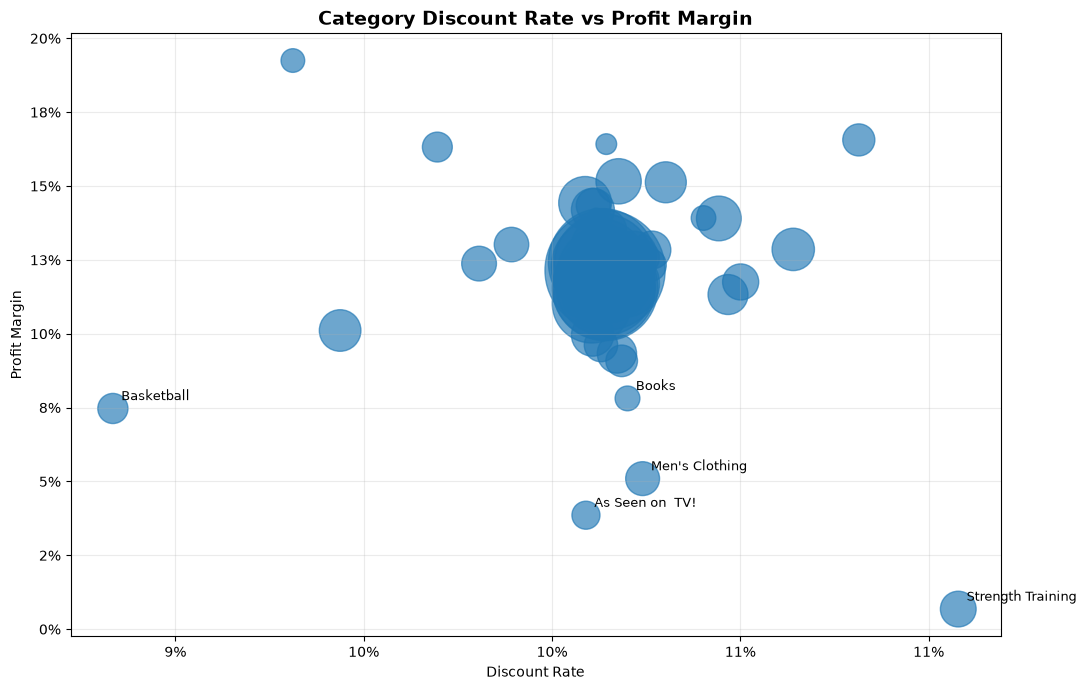

In [18]:
fig, ax = plt.subplots(figsize=(11, 7))

bubble_sizes = np.sqrt(
    discount_profitability["Net_Sales"]
) * 3

ax.scatter(
    discount_profitability["Discount_Rate"],
    discount_profitability["Profit_Margin"],
    s=bubble_sizes,
    alpha=0.65
)

low_margin_categories = discount_profitability.nsmallest(
    5,
    "Profit_Margin"
)

for _, row in low_margin_categories.iterrows():
    ax.annotate(
        row["Category Name"],
        (row["Discount_Rate"], row["Profit_Margin"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title(
    "Category Discount Rate vs Profit Margin",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Discount Rate")
ax.set_ylabel("Profit Margin")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 3.4 Product-Level Performance

Category-level analysis can hide substantial differences between
individual products.

This analysis evaluates product-level revenue, profitability,
sales volume, and margins to identify:

- Top revenue-generating products
- Top profit-generating products
- High-volume products
- Low-margin products
- Products that may require further investigation

The objective is to determine whether category performance is
concentrated among a small number of products.

In [19]:
product_performance = (
    df.groupby(["Product Card Id", "Product Name"])
      .agg(
          Gross_Sales=("Sales", "sum"),
          Net_Sales=("Order Item Total", "sum"),
          Discount=("Order Item Discount", "sum"),
          Profit=("Order Profit Per Order", "sum"),
          Units_Sold=("Order Item Quantity", "sum"),
          Order_Items=("Order Item Id", "nunique")
      )
      .reset_index()
)

product_performance["Profit_Margin"] = (
    product_performance["Profit"] /
    product_performance["Net_Sales"]
)

product_performance["Discount_Rate"] = (
    product_performance["Discount"] /
    product_performance["Gross_Sales"]
)

print("Number of products:", len(product_performance))

product_performance.head()

Number of products: 118


,Product Card Id,Product Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
0,19,Nike Men's Fingertrap Max Training Shoe,"7,999.36","7,256.88",742.48,602.38,64,64,0.08,0.09
1,24,Elevation Training Mask 2.0,"18,477.69","16,653.07","1,824.64","3,299.57",231,74,0.20,0.10
2,35,adidas Brazuca 2014 Official Match Ball,"10,399.35","9,386.55","1,012.80","1,642.73",65,65,0.18,0.10
3,37,adidas Kids' F5 Messi FG Soccer Cleat,"27,327.19","24,626.51","2,700.72","2,906.33",781,262,0.12,0.10
4,44,adidas Men's F10 Messi TRX FG Soccer Cleat,"56,330.61","50,354.21","5,976.47","8,213.07",939,305,0.16,0.11


In [20]:
product_performance.sort_values(
    "Net_Sales",
    ascending=False
).head(10)

,Product Card Id,Product Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,"6,929,653.69","6,226,935.29","702,728.00","756,220.77",17325,17325,0.12,0.10
35,365,Perfect Fitness Perfect Rip Deck,"4,421,143.14","3,973,180.36","447,968.17","493,828.30",73698,24515,0.12,0.10
92,957,Diamondback Women's Serene Classic Comfort Bi,"4,118,425.57","3,700,783.63","417,649.50","427,455.57",13729,13729,0.12,0.10
15,191,Nike Men's Free 5.0+ Running Shoe,"3,667,633.20","3,295,693.30","371,942.59","379,915.82",36680,12169,0.12,0.10
37,502,Nike Men's Dri-FIT Victory Golf Polo,"3,147,800.00","2,828,708.50","319,091.50","350,421.03",62956,21035,0.12,0.10
99,1073,Pelican Sunstream 100 Kayak,"3,099,845.09","2,785,518.09","314,327.00","324,076.37",15500,15500,0.12,0.10
36,403,Nike Men's CJ Elite 2 TD Football Cleat,"2,891,757.66","2,598,494.42","293,263.10","311,902.82",22246,22246,0.12,0.10
97,1014,O'Brien Men's Neoprene Life Vest,"2,888,993.91","2,596,454.02","292,550.63","318,451.43",57803,19298,0.12,0.10
44,627,Under Armour Girls' Toddler Spine Surge Runni,"1,269,082.67","1,140,770.96","128,314.03","126,278.51",31735,10617,0.11,0.10
105,1351,Dell Laptop,"663,000.00","595,395.00","67,605.00","69,656.81",442,442,0.12,0.10


In [21]:
product_performance.sort_values(
    "Profit",
    ascending=False
).head(10)

,Product Card Id,Product Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,"6,929,653.69","6,226,935.29","702,728.00","756,220.77",17325,17325,0.12,0.10
35,365,Perfect Fitness Perfect Rip Deck,"4,421,143.14","3,973,180.36","447,968.17","493,828.30",73698,24515,0.12,0.10
92,957,Diamondback Women's Serene Classic Comfort Bi,"4,118,425.57","3,700,783.63","417,649.50","427,455.57",13729,13729,0.12,0.10
15,191,Nike Men's Free 5.0+ Running Shoe,"3,667,633.20","3,295,693.30","371,942.59","379,915.82",36680,12169,0.12,0.10
37,502,Nike Men's Dri-FIT Victory Golf Polo,"3,147,800.00","2,828,708.50","319,091.50","350,421.03",62956,21035,0.12,0.10
99,1073,Pelican Sunstream 100 Kayak,"3,099,845.09","2,785,518.09","314,327.00","324,076.37",15500,15500,0.12,0.10
97,1014,O'Brien Men's Neoprene Life Vest,"2,888,993.91","2,596,454.02","292,550.63","318,451.43",57803,19298,0.12,0.10
36,403,Nike Men's CJ Elite 2 TD Football Cleat,"2,891,757.66","2,598,494.42","293,263.10","311,902.82",22246,22246,0.12,0.10
44,627,Under Armour Girls' Toddler Spine Surge Runni,"1,269,082.67","1,140,770.96","128,314.03","126,278.51",31735,10617,0.11,0.10
105,1351,Dell Laptop,"663,000.00","595,395.00","67,605.00","69,656.81",442,442,0.12,0.10


In [22]:
product_performance.sort_values(
    "Profit_Margin",
    ascending=True
).head(10)

,Product Card Id,Product Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
82,860,Bushnell Pro X7 Jolt Slope Rangefinder,"6,599.89","6,062.89",537.00,-255.95,11,11,-0.04,0.08
17,208,SOLE E35 Elliptical,"29,999.85","26,409.85","3,590.00",-965.12,15,15,-0.04,0.12
6,60,SOLE E25 Elliptical,"9,999.90","9,414.90",585.00,-169.56,10,10,-0.02,0.06
16,203,GoPro HERO3+ Black Edition Camera,"12,799.68","11,601.68","1,198.00",245.63,32,32,0.02,0.09
29,303,Garmin Forerunner 910XT GPS Watch,"13,999.65","12,593.65","1,406.00",391.13,35,35,0.03,0.10
7,61,Diamondback Girls' Clarity 24 Hybrid Bike 201,"8,399.72","7,624.22",775.50,284.42,28,28,0.04,0.09
33,359,Nike Men's Free TR 5.0 TB Training Shoe,"20,597.94","18,519.61","2,078.37",714.43,206,68,0.04,0.10
54,705,Cleveland Golf Women's 588 RTX CB Satin Chrom,"8,399.30","7,538.30",861.00,370.61,70,70,0.05,0.10
111,1357,Men's gala suit,"43,856.80","39,365.71","4,491.21","2,006.04",208,208,0.05,0.10
81,858,GolfBuddy VT3 GPS Watch,"11,799.41","10,637.41","1,162.00",569.02,59,59,0.05,0.10


### 3.5 Product Revenue & Profit Concentration

The product-level analysis indicates that a small number of products may
account for a substantial proportion of total revenue and profit.

This analysis quantifies that concentration by calculating the share of
total net sales and profit contributed by the top products.

It also identifies products generating negative profit.

Key questions:

- What percentage of revenue comes from the top 1, 5, and 10 products?
- What percentage of profit comes from the top 1, 5, and 10 products?
- How many products generate negative profit?
- Are the business's financial results highly dependent on a small
  number of products?

In [23]:
product_by_revenue = product_performance.sort_values(
    "Net_Sales",
    ascending=False
).copy()

total_product_revenue = product_by_revenue["Net_Sales"].sum()

for n in [1, 5, 10]:
    share = (
        product_by_revenue.head(n)["Net_Sales"].sum()
        / total_product_revenue
    )
    
    print(f"Top {n} products revenue share: {share:.2%}")

Top 1 products revenue share: 18.84%
Top 5 products revenue share: 60.58%
Top 10 products revenue share: 89.98%


In [24]:
product_by_profit = product_performance.sort_values(
    "Profit",
    ascending=False
).copy()

total_product_profit = product_by_profit["Profit"].sum()

for n in [1, 5, 10]:
    share = (
        product_by_profit.head(n)["Profit"].sum()
        / total_product_profit
    )
    
    print(f"Top {n} products profit share: {share:.2%}")

Top 1 products profit share: 19.06%
Top 5 products profit share: 60.70%
Top 10 products profit share: 89.70%


In [25]:
negative_profit_products = product_performance[
    product_performance["Profit"] < 0
].copy()

print(
    "Products with negative profit:",
    len(negative_profit_products)
)

print(
    "Share of products with negative profit:",
    len(negative_profit_products) / len(product_performance)
)

negative_profit_products.sort_values(
    "Profit",
    ascending=True
)

Products with negative profit: 3
Share of products with negative profit: 0.025423728813559324


,Product Card Id,Product Name,Gross_Sales,Net_Sales,Discount,Profit,Units_Sold,Order_Items,Profit_Margin,Discount_Rate
17,208,SOLE E35 Elliptical,"29,999.85","26,409.85","3,590.00",-965.12,15,15,-0.04,0.12
82,860,Bushnell Pro X7 Jolt Slope Rangefinder,"6,599.89","6,062.89",537.00,-255.95,11,11,-0.04,0.08
6,60,SOLE E25 Elliptical,"9,999.90","9,414.90",585.00,-169.56,10,10,-0.02,0.06


### 3.6 Product Revenue Concentration

The product-level analysis shows that revenue and profit are highly
concentrated among a small number of products.

A Pareto-style analysis is used to visualize the cumulative contribution
of products ranked by net sales.

This helps quantify the degree of product concentration and identify
the point at which the majority of business revenue is generated.

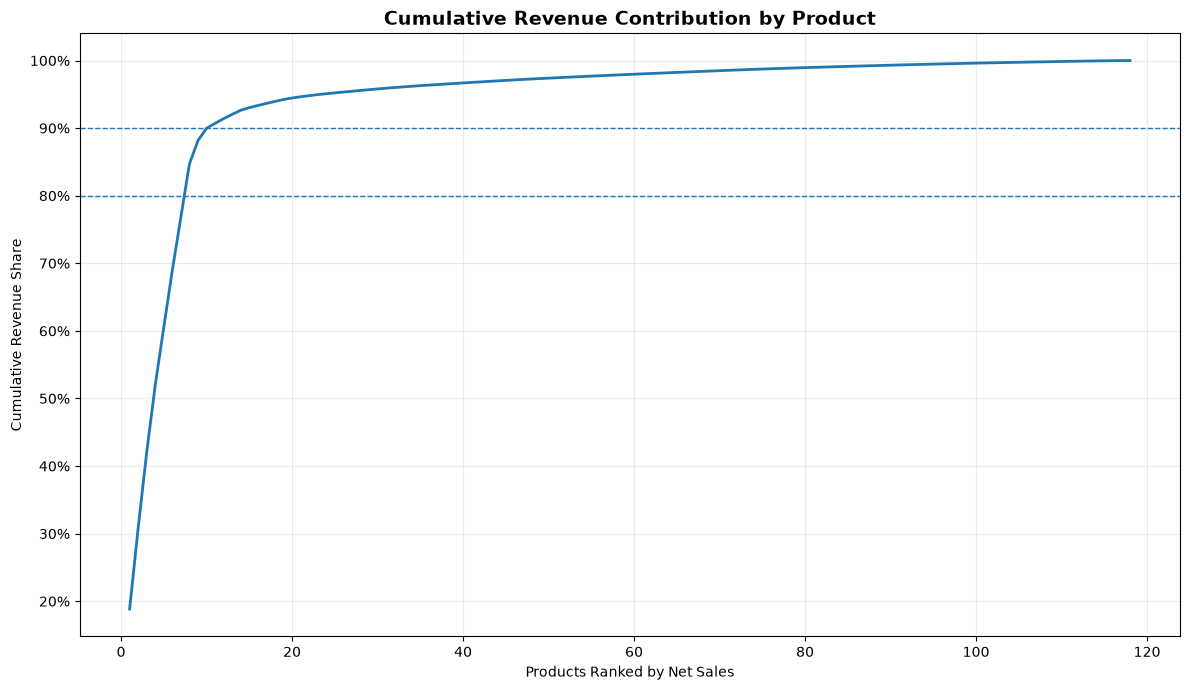

In [26]:
pareto_products = product_performance.sort_values(
    "Net_Sales",
    ascending=False
).reset_index(drop=True)

pareto_products["Cumulative_Revenue_Share"] = (
    pareto_products["Net_Sales"].cumsum()
    / pareto_products["Net_Sales"].sum()
)

product_rank = np.arange(1, len(pareto_products) + 1)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    product_rank,
    pareto_products["Cumulative_Revenue_Share"],
    linewidth=2
)

ax.axhline(
    0.80,
    linestyle="--",
    linewidth=1
)

ax.axhline(
    0.90,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Cumulative Revenue Contribution by Product",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Products Ranked by Net Sales")
ax.set_ylabel("Cumulative Revenue Share")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [27]:
for threshold in [0.50, 0.80, 0.90, 0.95]:
    products_needed = (
        pareto_products["Cumulative_Revenue_Share"] >= threshold
    ).idxmax() + 1

    print(
        f"Products required for {threshold:.0%} of revenue: "
        f"{products_needed}"
    )

Products required for 50% of revenue: 4
Products required for 80% of revenue: 8
Products required for 90% of revenue: 11
Products required for 95% of revenue: 24


### 3.7 Time-Based Sales & Demand Trends

Understanding how demand changes over time is essential for supply-chain
planning.

This analysis examines sales and order activity across the observed
period to identify:

- Overall revenue trends
- Changes in order volume
- Seasonal patterns
- Periods of unusually high or low demand

The analysis will use order-level metrics where appropriate to avoid
double-counting orders across order-item rows.

In [28]:
print("Order date range:")
print("Start:", df["order date (DateOrders)"].min())
print("End:", df["order date (DateOrders)"].max())

Order date range:
Start: 2015-01-01 00:00:00
End: 2018-01-31 23:38:00


In [29]:
monthly_performance = (
    df.assign(
        Month=df["order date (DateOrders)"].dt.to_period("M")
    )
    .groupby("Month")
    .agg(
        Net_Sales=("Order Item Total", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Order_Items=("Order Item Id", "nunique"),
        Units_Sold=("Order Item Quantity", "sum")
    )
    .reset_index()
)

monthly_performance["Month"] = (
    monthly_performance["Month"].dt.to_timestamp()
)

monthly_performance["Profit_Margin"] = (
    monthly_performance["Profit"] /
    monthly_performance["Net_Sales"]
)

monthly_performance

,Month,Net_Sales,Profit,Order_Items,Units_Sold,Profit_Margin
0,2015-01-01,"945,382.16","111,660.74",5322,11854,0.12
1,2015-02-01,"833,012.43","99,140.66",4729,10438,0.12
2,2015-03-01,"944,050.11","113,778.21",5362,12062,0.12
3,2015-04-01,"912,004.40","108,083.68",5126,11287,0.12
4,2015-05-01,"943,939.77","112,147.90",5357,11902,0.12
5,2015-06-01,"920,242.06","110,147.16",5134,11203,0.12
6,2015-07-01,"932,936.79","115,624.06",5299,11800,0.12
7,2015-08-01,"925,192.87","117,979.77",5273,11612,0.13
8,2015-09-01,"914,522.37","113,467.94",5140,11366,0.12
9,2015-10-01,"943,131.10","101,757.87",5302,11703,0.11


In [30]:
monthly_orders = (
    df.assign(
        Month=df["order date (DateOrders)"].dt.to_period("M")
    )
    .groupby("Month")["Order Id"]
    .nunique()
    .reset_index(name="Orders")
)

monthly_orders["Month"] = (
    monthly_orders["Month"].dt.to_timestamp()
)

monthly_performance = monthly_performance.merge(
    monthly_orders,
    on="Month",
    how="left"
)

monthly_performance

,Month,Net_Sales,Profit,Order_Items,Units_Sold,Profit_Margin,Orders
0,2015-01-01,"945,382.16","111,660.74",5322,11854,0.12,1787
1,2015-02-01,"833,012.43","99,140.66",4729,10438,0.12,1585
2,2015-03-01,"944,050.11","113,778.21",5362,12062,0.12,1781
3,2015-04-01,"912,004.40","108,083.68",5126,11287,0.12,1710
4,2015-05-01,"943,939.77","112,147.90",5357,11902,0.12,1776
5,2015-06-01,"920,242.06","110,147.16",5134,11203,0.12,1725
6,2015-07-01,"932,936.79","115,624.06",5299,11800,0.12,1763
7,2015-08-01,"925,192.87","117,979.77",5273,11612,0.13,1762
8,2015-09-01,"914,522.37","113,467.94",5140,11366,0.12,1706
9,2015-10-01,"943,131.10","101,757.87",5302,11703,0.11,1775


### 3.7.1 Monthly Order Composition

The monthly trend reveals a sharp structural change beginning in
October 2017. While order counts remain relatively high, units sold
and order-item counts decline substantially.

Before interpreting this as a genuine demand decline, the underlying
order composition is investigated to determine whether the change is
driven by purchasing behavior, product mix, or a change in the
underlying transaction structure.

In [31]:
monthly_performance["Units_per_Order"] = (
    monthly_performance["Units_Sold"] /
    monthly_performance["Orders"]
)

monthly_performance[
    [
        "Month",
        "Orders",
        "Units_Sold",
        "Units_per_Order",
        "Net_Sales",
        "Profit_Margin"
    ]
]

,Month,Orders,Units_Sold,Units_per_Order,Net_Sales,Profit_Margin
0,2015-01-01,1787,11854,6.63,"945,382.16",0.12
1,2015-02-01,1585,10438,6.59,"833,012.43",0.12
2,2015-03-01,1781,12062,6.77,"944,050.11",0.12
3,2015-04-01,1710,11287,6.60,"912,004.40",0.12
4,2015-05-01,1776,11902,6.70,"943,939.77",0.12
5,2015-06-01,1725,11203,6.49,"920,242.06",0.12
6,2015-07-01,1763,11800,6.69,"932,936.79",0.12
7,2015-08-01,1762,11612,6.59,"925,192.87",0.13
8,2015-09-01,1706,11366,6.66,"914,522.37",0.12
9,2015-10-01,1775,11703,6.59,"943,131.10",0.11


In [32]:
monthly_performance["AOV"] = (
    monthly_performance["Net_Sales"] /
    monthly_performance["Orders"]
)

monthly_performance[
    [
        "Month",
        "Orders",
        "Units_per_Order",
        "AOV"
    ]
]

,Month,Orders,Units_per_Order,AOV
0,2015-01-01,1787,6.63,529.03
1,2015-02-01,1585,6.59,525.56
2,2015-03-01,1781,6.77,530.07
3,2015-04-01,1710,6.60,533.34
4,2015-05-01,1776,6.70,531.50
5,2015-06-01,1725,6.49,533.47
6,2015-07-01,1763,6.69,529.18
7,2015-08-01,1762,6.59,525.08
8,2015-09-01,1706,6.66,536.06
9,2015-10-01,1775,6.59,531.34


In [33]:
pre_change = monthly_performance[
    monthly_performance["Month"] < "2017-10-01"
]

post_change = monthly_performance[
    monthly_performance["Month"] >= "2017-10-01"
]

print("BEFORE OCTOBER 2017")
print(
    "Average orders/month:",
    round(pre_change["Orders"].mean(), 0)
)
print(
    "Average units/order:",
    round(pre_change["Units_per_Order"].mean(), 2)
)
print(
    "Average AOV:",
    round(pre_change["AOV"].mean(), 2)
)

print("\nFROM OCTOBER 2017")
print(
    "Average orders/month:",
    round(post_change["Orders"].mean(), 0)
)
print(
    "Average units/order:",
    round(post_change["Units_per_Order"].mean(), 2)
)
print(
    "Average AOV:",
    round(post_change["AOV"].mean(), 2)
)

BEFORE OCTOBER 2017
Average orders/month: 1738.0
Average units/order: 6.54
Average AOV: 536.66

FROM OCTOBER 2017
Average orders/month: 2101.0
Average units/order: 1.05
Average AOV: 271.87


In [34]:
df.assign(
    Month=df["order date (DateOrders)"].dt.to_period("M")
).groupby(
    ["Month", "Order Status"]
).size().unstack(fill_value=0)

Order Status,CANCELED,CLOSED,COMPLETE,ON_HOLD,PAYMENT_REVIEW,PENDING,PENDING_PAYMENT,PROCESSING,SUSPECTED_FRAUD
Month,,,,,,,,,
2015-01,84,560,1760,270,50,646,1166,662,124
2015-02,127,566,1520,207,53,600,930,611,115
2015-03,115,632,1646,290,60,608,1214,677,120
2015-04,122,586,1658,350,76,566,1116,563,89
2015-05,134,575,1824,272,49,506,1171,690,136
2015-06,96,552,1701,267,36,567,1119,666,130
2015-07,73,632,1704,312,51,535,1204,686,102
2015-08,126,554,1790,313,56,560,1153,599,122
2015-09,92,622,1666,322,52,545,1138,581,122


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)


df = pd.read_csv(
    "../data/processed/supply_chain_cleaned.csv"
)

df.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Id,Customer Segment,Customer State,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,order date (DateOrders),Order Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Image,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,2018-01-31 22:56:00,77202,13.11,0.04,180517,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,2018-01-13 12:27:00,75939,16.39,0.05,179254,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,"95,125.00",2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,2018-01-13 12:06:00,75938,18.03,0.06,179253,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,19490,Home Office,CA,"90,027.00",2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,2018-01-13 11:45:00,75937,22.94,0.07,179252,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,19489,Corporate,PR,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,2018-01-13 11:24:00,75936,29.50,0.09,179251,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,1360,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [5]:

df[[
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]].dtypes

order date (DateOrders)       str
shipping date (DateOrders)    str
dtype: object

In [6]:
date_columns = [
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

df[date_columns].dtypes

order date (DateOrders)       datetime64[us]
shipping date (DateOrders)    datetime64[us]
dtype: object

In [7]:
monthly_performance = (
    df.assign(
        Month=df["order date (DateOrders)"].dt.to_period("M")
    )
    .groupby("Month")
    .agg(
        Net_Sales=("Order Item Total", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Order_Items=("Order Item Id", "nunique"),
        Units_Sold=("Order Item Quantity", "sum")
    )
    .reset_index()
)

monthly_performance["Month"] = (
    monthly_performance["Month"].dt.to_timestamp()
)


monthly_orders = (
    df.assign(
        Month=df["order date (DateOrders)"].dt.to_period("M")
    )
    .groupby("Month")["Order Id"]
    .nunique()
    .reset_index(name="Orders")
)

monthly_orders["Month"] = (
    monthly_orders["Month"].dt.to_timestamp()
)


monthly_performance = monthly_performance.merge(
    monthly_orders,
    on="Month",
    how="left"
)

monthly_performance

,Month,Net_Sales,Profit,Order_Items,Units_Sold,Orders
0,2015-01-01,"945,382.16","111,660.74",5322,11854,1787
1,2015-02-01,"833,012.43","99,140.66",4729,10438,1585
2,2015-03-01,"944,050.11","113,778.21",5362,12062,1781
3,2015-04-01,"912,004.40","108,083.68",5126,11287,1710
4,2015-05-01,"943,939.77","112,147.90",5357,11902,1776
5,2015-06-01,"920,242.06","110,147.16",5134,11203,1725
6,2015-07-01,"932,936.79","115,624.06",5299,11800,1763
7,2015-08-01,"925,192.87","117,979.77",5273,11612,1762
8,2015-09-01,"914,522.37","113,467.94",5140,11366,1706
9,2015-10-01,"943,131.10","101,757.87",5302,11703,1775


In [9]:
monthly_performance["Items_per_Order"] = (
    monthly_performance["Order_Items"] /
    monthly_performance["Orders"]
)

monthly_performance[
    [
        "Month",
        "Orders",
        "Order_Items",
        "Items_per_Order",
        "Units_Sold"
    ]
]

,Month,Orders,Order_Items,Items_per_Order,Units_Sold
0,2015-01-01,1787,5322,2.98,11854
1,2015-02-01,1585,4729,2.98,10438
2,2015-03-01,1781,5362,3.01,12062
3,2015-04-01,1710,5126,3.00,11287
4,2015-05-01,1776,5357,3.02,11902
5,2015-06-01,1725,5134,2.98,11203
6,2015-07-01,1763,5299,3.01,11800
7,2015-08-01,1762,5273,2.99,11612
8,2015-09-01,1706,5140,3.01,11366
9,2015-10-01,1775,5302,2.99,11703


In [10]:
pre_oct_2017 = monthly_performance[
    monthly_performance["Month"] < "2017-10-01"
]

post_oct_2017 = monthly_performance[
    monthly_performance["Month"] >= "2017-10-01"
]


comparison = pd.DataFrame({
    "Before Oct 2017": [
        pre_oct_2017["Orders"].mean(),
        pre_oct_2017["Order_Items"].mean(),
        pre_oct_2017["Units_Sold"].mean(),
        pre_oct_2017["Items_per_Order"].mean()
    ],
    
    "After Oct 2017": [
        post_oct_2017["Orders"].mean(),
        post_oct_2017["Order_Items"].mean(),
        post_oct_2017["Units_Sold"].mean(),
        post_oct_2017["Items_per_Order"].mean()
    ]
},
index=[
    "Average Orders",
    "Average Order Items",
    "Average Units Sold",
    "Average Items per Order"
])

comparison

,Before Oct 2017,After Oct 2017
Average Orders,"1,737.85","2,100.75"
Average Order Items,"5,210.97","2,139.25"
Average Units Sold,"11,372.33","2,198.00"
Average Items per Order,3.00,1.02


## Transaction Structure Change After October 2017

A significant structural change was observed in transaction composition after October 2017.

Before October 2017:
- Average orders per month: 1,737.85
- Average items per order: 3.00
- Average units sold per month: 11,372.33

After October 2017:
- Average orders per month: 2,100.75
- Average items per order: 1.02
- Average units sold per month: 2,198.00

Although order volume increased after October 2017, the number of items per order declined sharply.

This indicates that the observed decline in sales volume is likely caused by a structural change in the dataset's transaction recording process rather than an actual collapse in customer demand.

The dataset appears to transition from multi-item orders to predominantly single-item transactions.

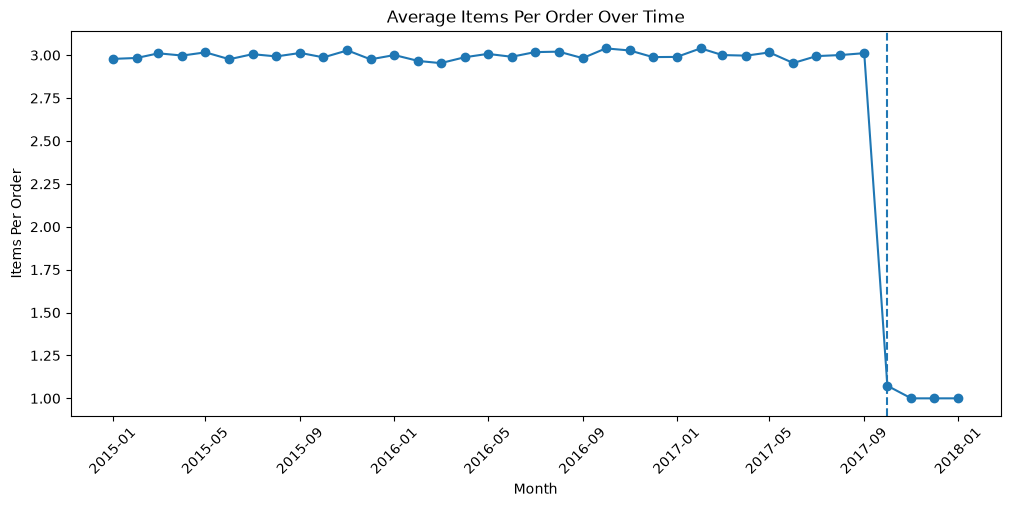

In [11]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_performance["Month"],
    monthly_performance["Items_per_Order"],
    marker="o"
)

plt.axvline(
    pd.Timestamp("2017-10-01"),
    linestyle="--"
)

plt.title("Average Items Per Order Over Time")
plt.xlabel("Month")
plt.ylabel("Items Per Order")

plt.xticks(rotation=45)

plt.show()

### Interpretation

The time series shows a clear structural break in average items per order around October 2017.

From January 2015 through September 2017, orders consistently contained approximately 3 items on average. Beginning in October 2017, this metric abruptly declined to approximately 1 item per order and remained at that level through January 2018.

This indicates a major change in transaction composition. Since the number of orders did not decline during the same period, the reduction in units sold and order items should not be interpreted as a straightforward decline in customer demand.

Instead, the pattern suggests that the dataset's underlying transaction structure or recording methodology changed around October 2017.

## 3.7.4 Monthly Sales and Profit Trends

Monthly sales and profit are analyzed to identify long-term trends, seasonal patterns, and significant changes in business performance over the observation period.

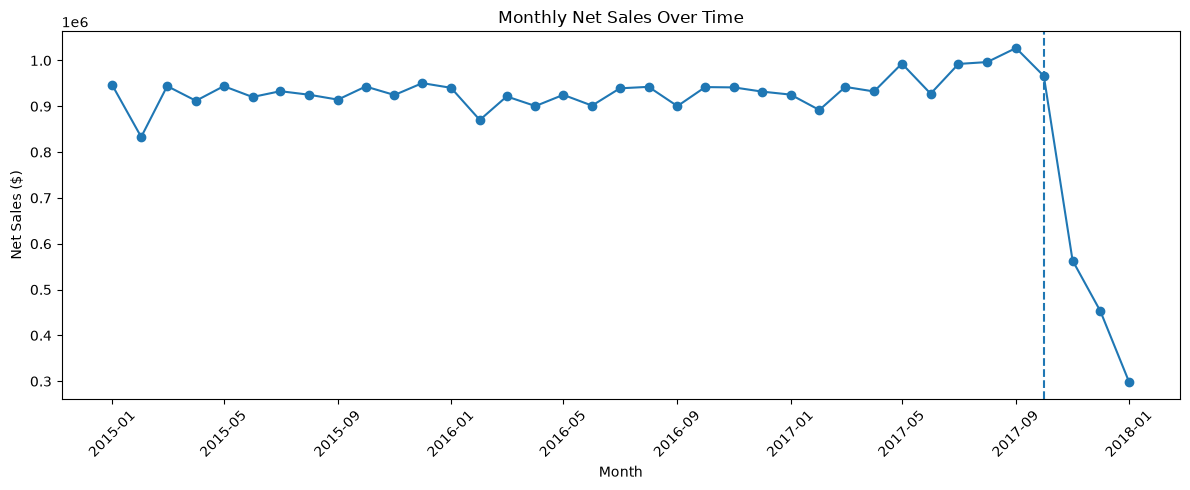

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance["Month"],
    monthly_performance["Net_Sales"],
    marker="o"
)

plt.axvline(
    pd.Timestamp("2017-10-01"),
    linestyle="--"
)

plt.title("Monthly Net Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Net Sales ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

Monthly net sales remained stable between January 2015 and September 2017, consistently generating approximately $0.9M-$1.0M in monthly revenue.

A sharp decline is observed after October 2017, with monthly sales decreasing significantly through January 2018.

However, previous transaction structure analysis showed that this decline coincides with a major change in order composition:

- Items per order decreased from approximately 3.0 to 1.0
- Units sold decreased significantly
- Number of orders remained stable or increased

Therefore, the decline in revenue should be interpreted alongside the structural change in transaction recording. The pattern suggests a change in the underlying order-level data structure rather than a direct indication of business performance deterioration.

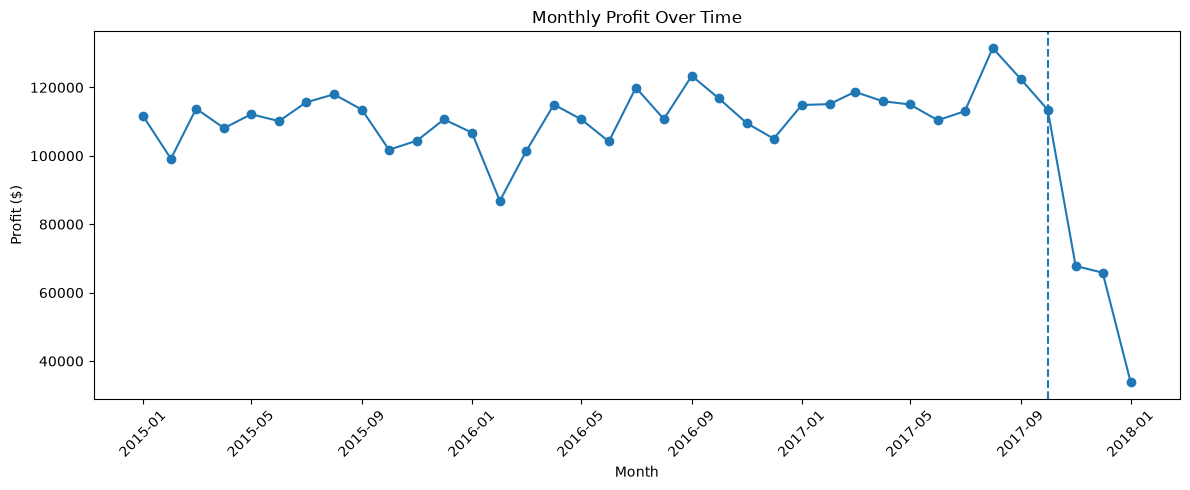

In [13]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_performance["Month"],
    monthly_performance["Profit"],
    marker="o"
)

plt.axvline(
    pd.Timestamp("2017-10-01"),
    linestyle="--"
)

plt.title("Monthly Profit Over Time")
plt.xlabel("Month")
plt.ylabel("Profit ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

Monthly profit followed the same pattern as net sales.

Between January 2015 and September 2017, monthly profit remained stable, generally ranging between $100K and $120K.

A sharp decline occurred after October 2017, with profit falling significantly by January 2018.

However, transaction-level analysis revealed that this decline coincided with a structural change in the dataset:

- Orders remained relatively stable
- Order items decreased significantly
- Units sold dropped sharply
- Items per order declined from approximately 3 to 1

Therefore, the observed profit decline is likely influenced by incomplete transaction-level data or a change in data recording structure rather than a direct indicator of business performance deterioration.

In [14]:
order_behavior = (
    df.assign(
        Month=df["order date (DateOrders)"].dt.to_period("M")
    )
    .groupby("Month")
    .agg(
        Orders=("Order Id", "nunique"),
        Customers=("Customer Id", "nunique"),
        Avg_Order_Value=("Sales", "mean"),
        Revenue=("Sales", "sum")
    )
    .reset_index()
)

order_behavior.head()

,Month,Orders,Customers,Avg_Order_Value,Revenue
0,2015-01,1787,1668,197.59,"1,051,590.08"
1,2015-02,1585,1500,196.03,"927,009.90"
2,2015-03,1781,1654,196.06,"1,051,253.69"
3,2015-04,1710,1596,197.91,"1,014,463.28"
4,2015-05,1776,1654,196.09,"1,050,478.44"


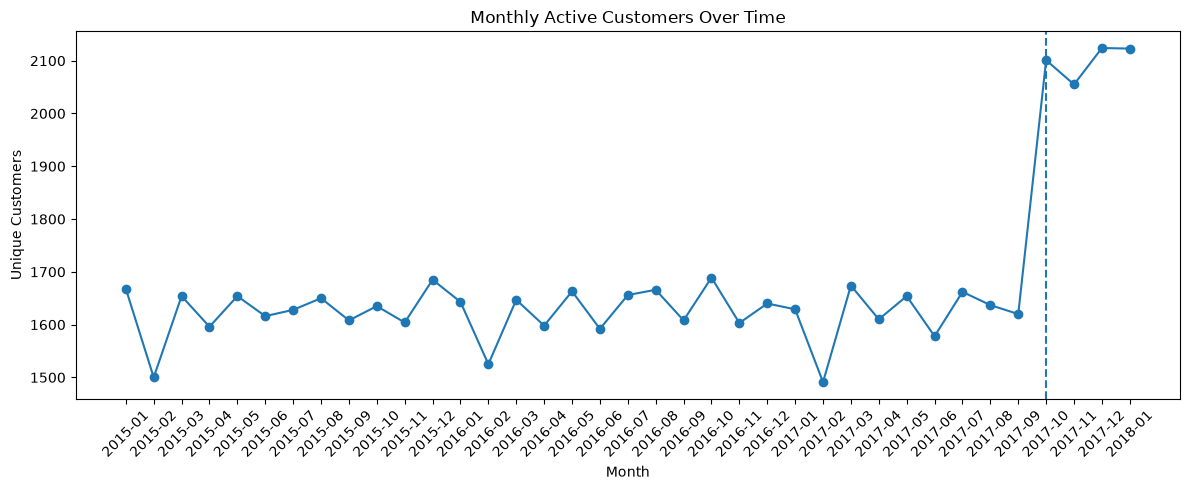

In [15]:
plt.figure(figsize=(12,5))

plt.plot(
    order_behavior["Month"].astype(str),
    order_behavior["Customers"],
    marker="o"
)

plt.axvline(
    "2017-10",
    linestyle="--"
)

plt.title("Monthly Active Customers Over Time")
plt.xlabel("Month")
plt.ylabel("Unique Customers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Customer Activity Analysis

Monthly active customers remained stable between January 2015 and September 2017, averaging around 1,600 customers per month.

After October 2017, active customers increased significantly to approximately 2,100 customers per month.

Despite this growth in customer activity, revenue and profit declined sharply during the same period.

This indicates that the decline was not caused by customer loss. Instead, the reduction was driven by a decrease in order value and order composition, where the average items per order dropped from approximately 3 items to 1 item.

The sudden structural change suggests a possible change in transaction recording methodology or incomplete post-October 2017 order-level data rather than a true business performance decline.

In [16]:
aov_analysis = (
    df.assign(
        Month=df["order date (DateOrders)"].dt.to_period("M")
    )
    .groupby("Month")
    .agg(
        Revenue=("Sales", "sum"),
        Orders=("Order Id", "nunique")
    )
    .reset_index()
)

aov_analysis["Average_Order_Value"] = (
    aov_analysis["Revenue"] /
    aov_analysis["Orders"]
)

aov_analysis.head()

,Month,Revenue,Orders,Average_Order_Value
0,2015-01,"1,051,590.08",1787,588.47
1,2015-02,"927,009.90",1585,584.86
2,2015-03,"1,051,253.69",1781,590.26
3,2015-04,"1,014,463.28",1710,593.25
4,2015-05,"1,050,478.44",1776,591.49


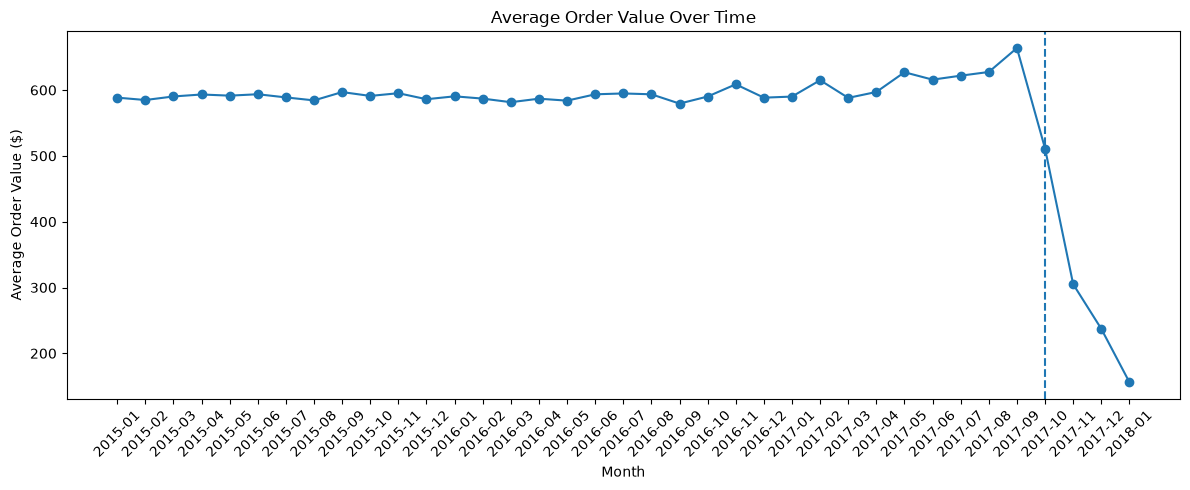

In [17]:
plt.figure(figsize=(12,5))

plt.plot(
    aov_analysis["Month"].astype(str),
    aov_analysis["Average_Order_Value"],
    marker="o"
)

plt.axvline(
    "2017-10",
    linestyle="--"
)

plt.title("Average Order Value Over Time")
plt.xlabel("Month")
plt.ylabel("Average Order Value ($)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Average Order Value Analysis

Average Order Value remained stable between January 2015 and September 2017, averaging approximately $600 per order.

A sharp decline occurred after October 2017, with AOV falling to nearly $150 by January 2018.

This decline explains the reduction in revenue and profit observed during the same period.

However, customer activity did not decrease. Monthly active customers actually increased after October 2017, while order frequency remained relatively stable.

The primary driver of declining revenue was therefore not customer loss, but a significant reduction in order value caused by fewer items per order.

The simultaneous drop in items per order, units sold, and AOV suggests a structural change in transaction recording or incomplete post-October 2017 order data rather than an actual deterioration in customer purchasing behavior.

# 5. Product Performance Analysis

In [22]:
product_performance = (
    df.groupby(
        ["Product Card Id", "Product Name"]
    )
    .agg(
        Revenue=("Sales", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Units_Sold=("Order Item Quantity", "sum"),
        Orders=("Order Id", "nunique")
    )
    .reset_index()
)

product_performance = product_performance.sort_values(
    "Revenue",
    ascending=False
)

product_performance.head(10)

,Product Card Id,Product Name,Revenue,Profit,Units_Sold,Orders
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,"6,929,653.69","756,220.77",17325,15164
35,365,Perfect Fitness Perfect Rip Deck,"4,421,143.14","493,828.30",73698,20359
92,957,Diamondback Women's Serene Classic Comfort Bi,"4,118,425.57","427,455.57",13729,12299
15,191,Nike Men's Free 5.0+ Running Shoe,"3,667,633.20","379,915.82",36680,11092
37,502,Nike Men's Dri-FIT Victory Golf Polo,"3,147,800.00","350,421.03",62956,17869
99,1073,Pelican Sunstream 100 Kayak,"3,099,845.09","324,076.37",15500,13727
36,403,Nike Men's CJ Elite 2 TD Football Cleat,"2,891,757.66","311,902.82",22246,18783
97,1014,O'Brien Men's Neoprene Life Vest,"2,888,993.91","318,451.43",57803,16623
44,627,Under Armour Girls' Toddler Spine Surge Runni,"1,269,082.67","126,278.51",31735,9825
105,1351,Dell Laptop,"663,000.00","69,656.81",442,442


In [23]:
product_performance["Profit_Margin"] = (
    product_performance["Profit"] /
    product_performance["Revenue"]
)

product_performance.head(10)

,Product Card Id,Product Name,Revenue,Profit,Units_Sold,Orders,Profit_Margin
96,1004,Field & Stream Sportsman 16 Gun Fire Safe,"6,929,653.69","756,220.77",17325,15164,0.11
35,365,Perfect Fitness Perfect Rip Deck,"4,421,143.14","493,828.30",73698,20359,0.11
92,957,Diamondback Women's Serene Classic Comfort Bi,"4,118,425.57","427,455.57",13729,12299,0.10
15,191,Nike Men's Free 5.0+ Running Shoe,"3,667,633.20","379,915.82",36680,11092,0.10
37,502,Nike Men's Dri-FIT Victory Golf Polo,"3,147,800.00","350,421.03",62956,17869,0.11
99,1073,Pelican Sunstream 100 Kayak,"3,099,845.09","324,076.37",15500,13727,0.10
36,403,Nike Men's CJ Elite 2 TD Football Cleat,"2,891,757.66","311,902.82",22246,18783,0.11
97,1014,O'Brien Men's Neoprene Life Vest,"2,888,993.91","318,451.43",57803,16623,0.11
44,627,Under Armour Girls' Toddler Spine Surge Runni,"1,269,082.67","126,278.51",31735,9825,0.10
105,1351,Dell Laptop,"663,000.00","69,656.81",442,442,0.11


## Top Products by Revenue

This analysis identifies products contributing the highest share of total revenue.

Understanding revenue concentration helps identify key products that drive business performance and require priority in inventory planning and supply chain management.

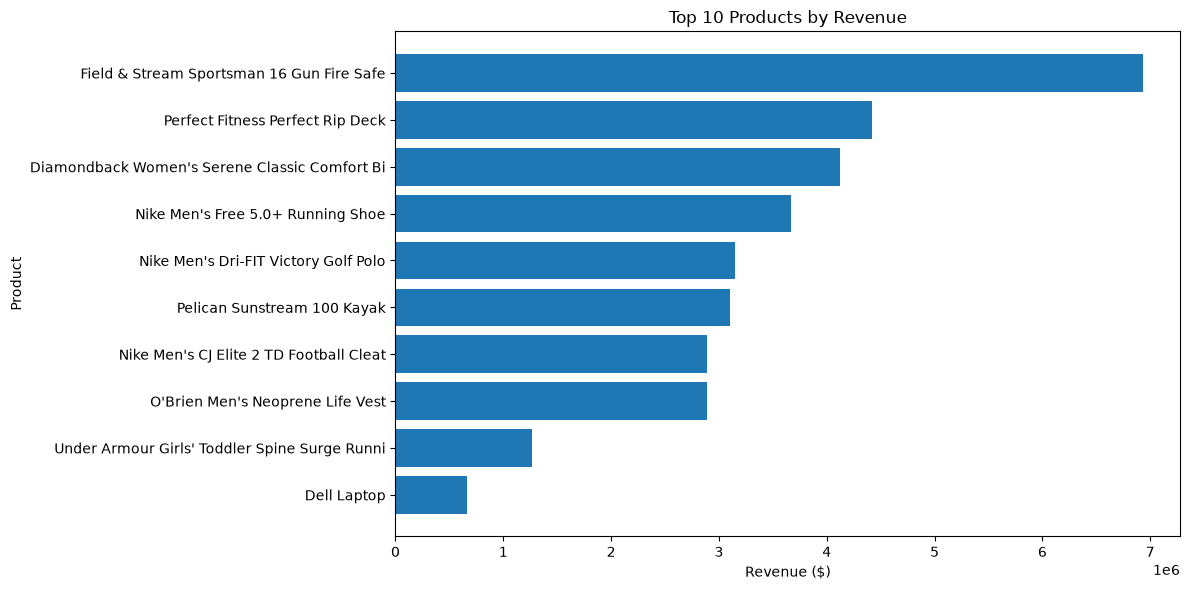

In [24]:
top_revenue_products = (
    product_performance
    .head(10)
    .sort_values("Revenue")
)


plt.figure(figsize=(12,6))

plt.barh(
    top_revenue_products["Product Name"],
    top_revenue_products["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

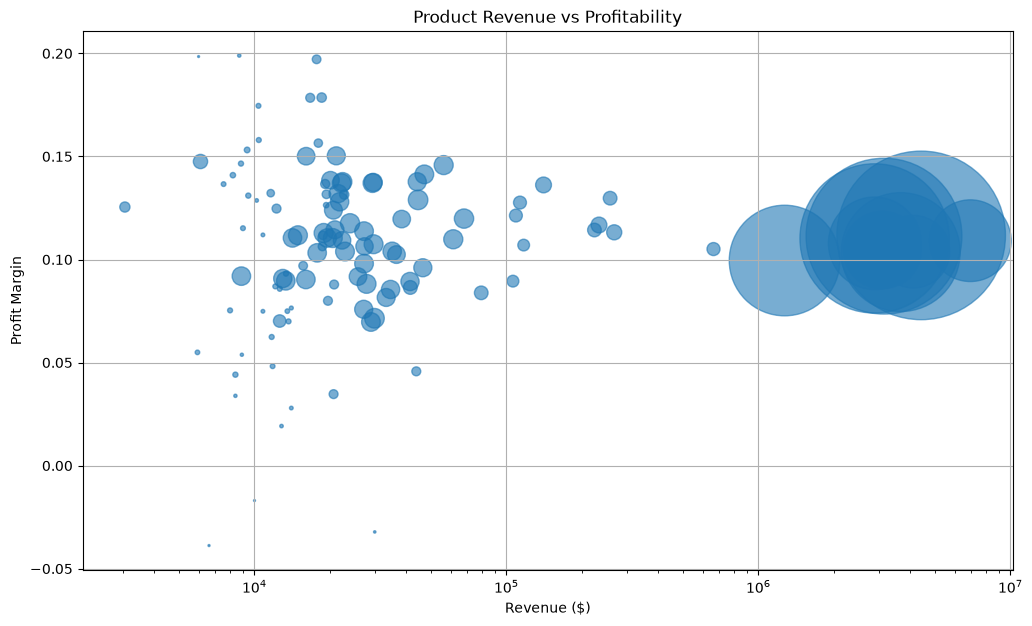

In [25]:
plt.figure(figsize=(12,7))

plt.scatter(
    product_performance["Revenue"],
    product_performance["Profit_Margin"],
    s=product_performance["Units_Sold"]/5,
    alpha=0.6
)

plt.xlabel("Revenue ($)")
plt.ylabel("Profit Margin")

plt.title(
    "Product Revenue vs Profitability"
)

plt.xscale("log")

plt.grid(True)

plt.show()

## Product Revenue Analysis

The revenue analysis shows that a small number of products contribute a large proportion of total sales.

The top-performing products act as key revenue drivers and should receive priority in inventory planning, demand forecasting, and supply chain management.

High-performing products include:
- Field & Stream Sportsman 16 Gun Fire Safe
- Perfect Fitness Perfect Rip Deck
- Diamondback Women's Serene Classic Comfort Bike
- Nike Men's Free 5.0+ Running Shoe

These products combine strong demand with consistent profitability, making them strategic products for the business.

## Product Profitability Analysis

The relationship between revenue and profitability shows that the highest revenue products maintain consistent profit margins.

Most major products operate around a 10-12% profit margin, indicating stable pricing and cost structures.

Only a few products generate negative profit, and their contribution is negligible compared to the overall portfolio.

This suggests that product profitability is generally healthy, while low-performing products may require pricing review or inventory optimization.

In [26]:
customer_segment = (
    df.groupby("Customer Segment")
    .agg(
        Customers=("Customer Id","nunique"),
        Orders=("Order Id","nunique"),
        Revenue=("Sales","sum"),
        Profit=("Order Profit Per Order","sum")
    )
    .sort_values("Revenue", ascending=False)
)

customer_segment

,Customers,Orders,Revenue,Profit
Customer Segment,,,,
Consumer,10695,34119,"19,095,790.16","2,073,487.67"
Corporate,6239,19856,"11,168,406.84","1,202,574.96"
Home Office,3718,11777,"6,520,538.02","690,840.34"


## Customer Segment Performance Analysis

Customer segmentation reveals that the Consumer segment is the primary revenue contributor.

The Consumer segment generates the highest revenue and profit due to its large customer base and order volume.

Corporate customers represent an important secondary segment, contributing significant revenue despite having fewer customers, suggesting potentially higher-value transactions.

The Home Office segment contributes the least revenue but remains consistently profitable.

Business Focus:
- Maintain strong consumer demand through inventory availability and customer experience.
- Develop corporate relationships to increase high-value orders.
- Identify growth opportunities within the Home Office segment.

In [27]:
customer_segment["Revenue_per_Customer"] = (
    customer_segment["Revenue"] /
    customer_segment["Customers"]
)

customer_segment["Profit_Margin"] = (
    customer_segment["Profit"] /
    customer_segment["Revenue"]
)

customer_segment

,Customers,Orders,Revenue,Profit,Revenue_per_Customer,Profit_Margin
Customer Segment,,,,,,
Consumer,10695,34119,"19,095,790.16","2,073,487.67","1,785.49",0.11
Corporate,6239,19856,"11,168,406.84","1,202,574.96","1,790.10",0.11
Home Office,3718,11777,"6,520,538.02","690,840.34","1,753.78",0.11


## Customer Segment Value Analysis

Analysis of revenue efficiency shows that all customer segments generate similar revenue per customer.

The Corporate segment has the highest revenue per customer, indicating that business customers provide slightly higher individual value compared to Consumer and Home Office customers.

However, profit margins remain consistent across all segments at approximately 11%, suggesting that profitability is driven more by overall sales volume rather than customer segment differences.

Business Insights:
- Consumer customers remain the largest revenue source because of their larger customer base.
- Corporate customers represent a potential growth opportunity due to their high individual spending.
- Segment-specific pricing strategies may not be necessary since profitability is consistent across groups.

In [28]:
country_performance = (
    df.groupby("Order Country")
    .agg(
        Revenue=("Sales", "sum"),
        Profit=("Order Profit Per Order", "sum"),
        Orders=("Order Id", "nunique")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

country_performance.head(10)

,Revenue,Profit,Orders
Order Country,,,
Estados Unidos,"4,879,667.67","540,413.07",8270
Francia,"2,879,942.36","327,828.58",4866
México,"2,633,195.29","303,278.37",4395
Alemania,"2,074,171.82","194,827.08",3518
Australia,"1,694,621.67","170,041.58",3798
Reino Unido,"1,612,094.85","180,942.88",2785
Brasil,"1,594,319.95","186,713.64",2650
China,"1,172,902.11","122,190.92",2616
Italia,"1,072,181.67","121,545.47",1880


## Geographic Performance Analysis

Geographic analysis shows that the United States is the strongest market, generating the highest revenue, profit, and order volume.

European markets such as France and Germany also demonstrate strong performance, contributing significant revenue and maintaining healthy profitability.

Mexico stands out as a high-value market with strong revenue and profit contribution, indicating good market acceptance.

Emerging markets including India, China, and Brazil provide additional growth opportunities. Improving regional operations and customer targeting could help increase future revenue.

Business Recommendations:
- Prioritize inventory availability in top-performing countries.
- Strengthen marketing strategies in high-growth international markets.
- Analyze logistics performance in developing regions to improve customer experience.

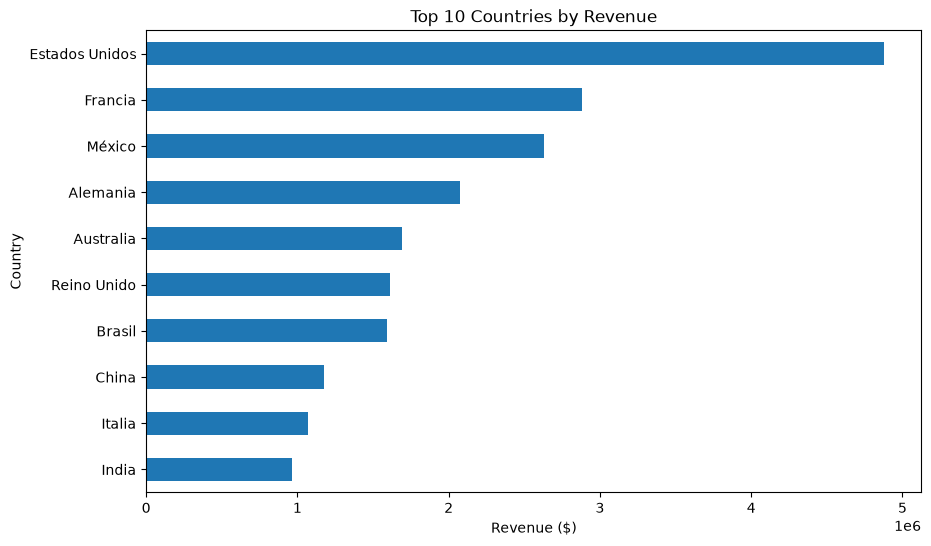

In [29]:
plt.figure(figsize=(10,6))

country_performance.head(10)["Revenue"].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Country")

plt.show()

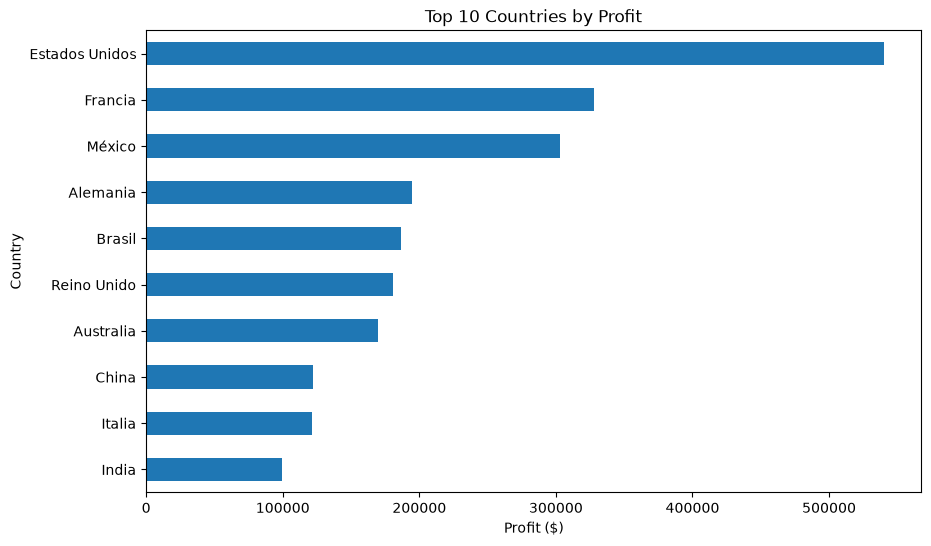

In [30]:
plt.figure(figsize=(10,6))

country_performance.head(10)["Profit"].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("Country")

plt.show()

## Geographic Performance Analysis

Geographic analysis was performed to identify the strongest revenue-generating and profitable markets.

### Revenue Performance

The United States is the dominant market, generating the highest revenue among all countries. It significantly outperforms other regions, indicating strong customer demand and market presence.

France and Mexico are the next strongest contributors, both generating over $2.5M in revenue. These markets represent important international growth opportunities.

Other countries such as Germany, Australia, the United Kingdom, and Brazil also contribute meaningful revenue, demonstrating a diversified global customer base.

### Profit Performance

Profit distribution follows a similar pattern to revenue performance.

The United States generates the highest profit contribution, followed by France and Mexico.

However, countries with high revenue do not always maintain the same ranking for profitability. Factors such as pricing strategy, operational costs, discounts, and logistics expenses may influence profit generation.

### Business Recommendations

- Prioritize inventory availability and supply chain efficiency in top-performing markets.
- Continue investing in the US, France, and Mexico due to their strong revenue and profit contribution.
- Investigate profitability differences between countries to identify opportunities for margin improvement.
- Improve regional strategies in emerging markets such as India and China to increase future growth.

In [31]:
delivery_status = (
    df["Delivery Status"]
    .value_counts()
)

delivery_status

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [32]:
late_delivery = (
    df["Late_delivery_risk"]
    .value_counts(normalize=True)
    * 100
)

late_delivery

Late_delivery_risk
1   54.83
0   45.17
Name: proportion, dtype: float64

## Shipping & Delivery Performance Analysis

Delivery performance analysis reveals significant operational challenges within the supply chain.

More than half of all orders (54.83%) experienced late delivery, making delayed shipments the largest operational issue.

Only 17.84% of orders were delivered on time, while 23.04% were shipped ahead of schedule. This indicates that while the company has the capability for fast fulfillment, delivery consistency remains a challenge.

The late delivery risk analysis confirms that 54.83% of orders are classified as high-risk shipments.

Business Recommendations:
- Investigate causes of late deliveries across regions and shipping modes.
- Improve inventory planning and warehouse operations.
- Analyze shipping methods associated with delays.
- Optimize delivery forecasting to improve customer expectations.

In [33]:
shipping_mode_analysis = (
    df.groupby("Shipping Mode")
    .agg(
        Orders=("Order Id","nunique"),
        Avg_Delivery_Days=("Days for shipping (real)","mean"),
        Avg_Scheduled_Days=("Days for shipment (scheduled)","mean"),
        Late_Risk=("Late_delivery_risk","mean")
    )
)

shipping_mode_analysis["Late_Risk"] = (
    shipping_mode_analysis["Late_Risk"] * 100
)

shipping_mode_analysis.sort_values(
    "Late_Risk",
    ascending=False
)

,Orders,Avg_Delivery_Days,Avg_Scheduled_Days,Late_Risk
Shipping Mode,,,,
First Class,10079,2.00,1.00,95.32
Second Class,12778,3.99,2.00,76.63
Same Day,3571,0.48,0.00,45.74
Standard Class,39324,4.00,4.00,38.07


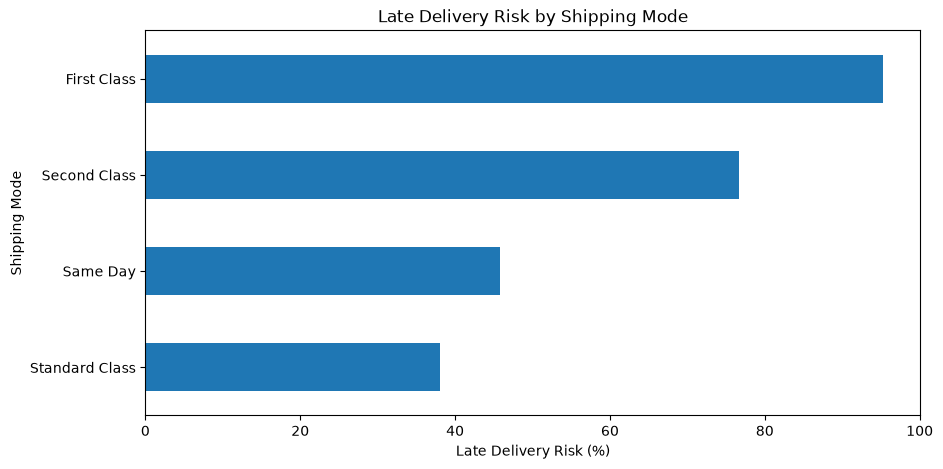

In [34]:
plt.figure(figsize=(10,5))

shipping_mode_analysis["Late_Risk"].sort_values().plot(
    kind="barh"
)

plt.title("Late Delivery Risk by Shipping Mode")
plt.xlabel("Late Delivery Risk (%)")
plt.ylabel("Shipping Mode")

plt.show()

## Shipping Mode Performance Insights

The analysis of shipping modes reveals that faster shipping options have significantly higher late delivery risk.

First Class shipping shows the highest late delivery risk at 95.32%, despite being designed as a premium delivery option. This indicates that delivery commitments for this category may be too aggressive compared to actual operational capabilities.

Second Class shipping also performs poorly with a late delivery risk of 76.63%, suggesting delays in fulfillment or transportation processes.

Standard Class shipping demonstrates the best reliability with the lowest late delivery risk of 38.07% while handling the highest number of orders. This suggests that realistic delivery expectations contribute significantly to successful fulfillment.

Key Business Recommendations:
- Reevaluate promised delivery timelines for premium shipping methods.
- Use historical delivery performance to set realistic customer expectations.
- Investigate carrier and fulfillment issues affecting First Class and Second Class shipments.
- Promote reliable shipping options where delivery accuracy is more important than speed.

In [35]:
discount_analysis = (
    df.groupby("Order Item Discount Rate")
    .agg(
        Orders=("Order Id", "nunique"),
        Revenue=("Sales", "sum"),
        Profit=("Order Profit Per Order", "sum")
    )
    .reset_index()
)

discount_analysis

,Order Item Discount Rate,Orders,Revenue,Profit
0,0.00,9400,"2,042,369.18","267,412.40"
1,0.01,9356,"2,042,793.05","238,653.96"
2,0.02,9364,"2,042,818.15","237,401.16"
3,0.03,9403,"2,043,343.82","222,475.43"
4,0.04,9364,"2,043,377.90","234,683.30"
5,0.05,9366,"2,043,412.89","238,468.23"
6,0.06,9376,"2,043,421.44","241,415.97"
7,0.07,9384,"2,043,451.89","233,404.92"
8,0.09,9385,"2,043,478.43","229,769.42"
9,0.10,9377,"2,043,500.52","221,921.32"


## Discount Impact Analysis

Discount analysis shows that increasing discounts has limited impact on revenue generation but significantly reduces profitability.

Revenue remains almost constant across different discount levels, indicating that higher discounts do not create substantial additional demand.

However, profitability decreases as discount rates increase. Products sold without discounts generate the highest profit, while heavily discounted products experience significant margin reduction.

This suggests that discount strategies should be applied selectively rather than broadly.

Business Recommendations:
- Avoid excessive discounting on high-performing products.
- Use discounts strategically for inventory clearance and customer acquisition.
- Evaluate product-level discount effectiveness before applying promotions.
- Focus on value-based pricing to protect profit margins.

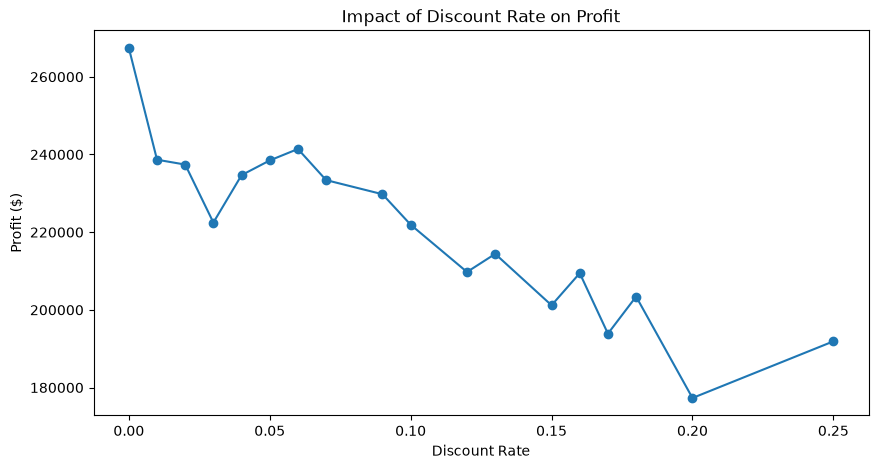

In [36]:
plt.figure(figsize=(10,5))

plt.plot(
    discount_analysis["Order Item Discount Rate"],
    discount_analysis["Profit"],
    marker="o"
)

plt.title("Impact of Discount Rate on Profit")
plt.xlabel("Discount Rate")
plt.ylabel("Profit ($)")

plt.show()

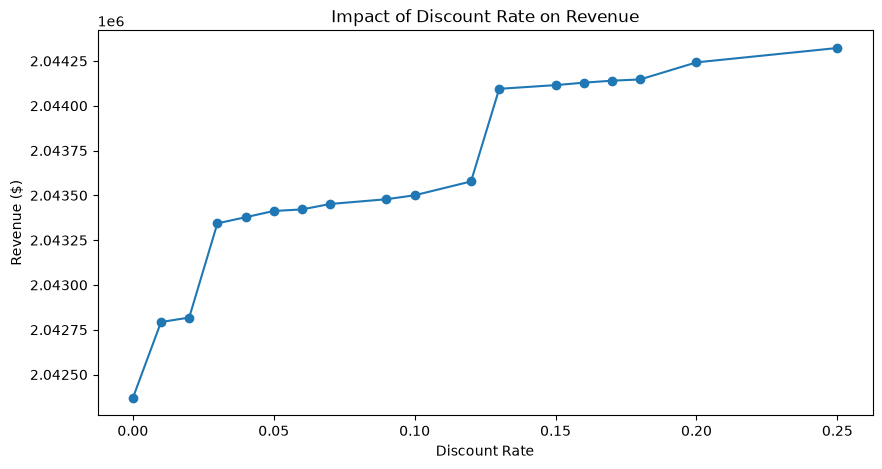

In [37]:
plt.figure(figsize=(10,5))

plt.plot(
    discount_analysis["Order Item Discount Rate"],
    discount_analysis["Revenue"],
    marker="o"
)

plt.title("Impact of Discount Rate on Revenue")
plt.xlabel("Discount Rate")
plt.ylabel("Revenue ($)")

plt.show()

## Discount Strategy Analysis

The relationship between discount rates, revenue, and profitability was analyzed to understand whether increasing discounts creates additional business value.

### Key Findings:

- Increasing discount rates has a negligible impact on revenue.
- Revenue remains almost constant across different discount levels, suggesting that higher discounts do not significantly increase purchase volume.
- Profit shows a clear declining trend as discount rates increase.
- Orders remain relatively stable across discount levels, indicating that customers are not highly sensitive to these discounts.

### Business Insights:

- Large discounts reduce profit margins without generating proportional revenue growth.
- Applying discounts universally can negatively impact profitability.
- Discount strategies should be targeted towards:
    - clearing slow-moving inventory
    - attracting new customers
    - seasonal campaigns
    - selected product categories

A data-driven discount strategy is recommended instead of broad discounting.

# Correlation Analysis

Correlation analysis helps identify relationships between numerical variables and understand which factors influence sales and profitability.

In [38]:
numeric_cols = [
    "Sales",
    "Order Item Quantity",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Profit Per Order",
    "Sales per customer",
    "Days for shipping (real)",
    "Days for shipment (scheduled)"
]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,Sales,Order Item Quantity,Order Item Discount,Order Item Discount Rate,Order Profit Per Order,Sales per customer,Days for shipping (real),Days for shipment (scheduled)
Sales,1.00,0.11,0.62,0.00,0.13,0.99,0.00,0.01
Order Item Quantity,0.11,1.00,0.07,-0.00,0.02,0.11,-0.00,-0.00
Order Item Discount,0.62,0.07,1.00,0.66,0.06,0.50,0.00,0.00
Order Item Discount Rate,0.00,-0.00,0.66,1.00,-0.02,-0.12,0.00,0.00
Order Profit Per Order,0.13,0.02,0.06,-0.02,1.00,0.13,-0.01,-0.00
Sales per customer,0.99,0.11,0.50,-0.12,0.13,1.00,0.00,0.01
Days for shipping (real),0.00,-0.00,0.00,0.00,-0.01,0.00,1.00,0.52
Days for shipment (scheduled),0.01,-0.00,0.00,0.00,-0.00,0.01,0.52,1.00


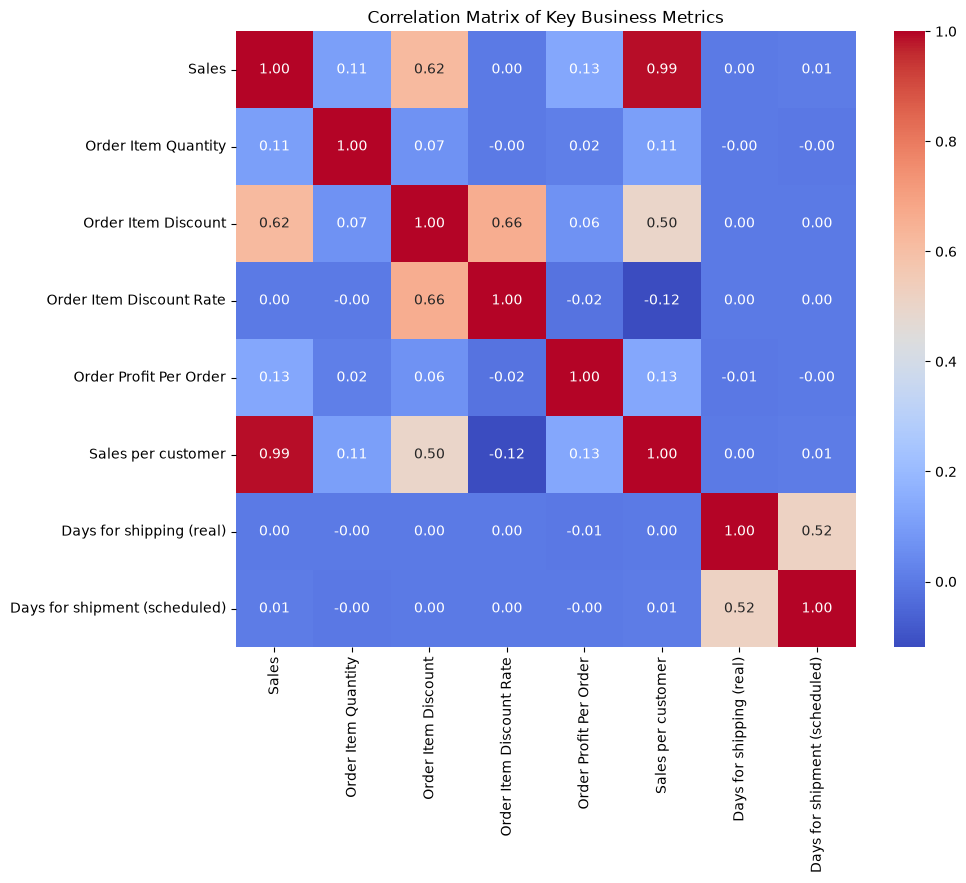

In [42]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Key Business Metrics")

plt.show()

# Correlation Analysis Insights

Correlation analysis was performed to identify relationships between important business metrics.

## Key Findings:

### 1. Sales and Sales per Customer
- Sales and Sales per customer show a very strong positive correlation (**0.99**).
- This is expected because higher customer spending directly contributes to total sales.

### 2. Discounts and Revenue
- Order Item Discount has a moderate positive correlation with Sales (**0.62**).
- However, previous discount analysis showed that increasing discounts does not significantly improve revenue.
- This suggests that discounts increase transaction value but reduce profitability.

### 3. Discounts and Profitability
- Order Item Discount has a weak correlation with Order Profit Per Order (**0.06**).
- Higher discounts do not create meaningful profit improvements.

### 4. Shipping Performance
- Actual shipping days and scheduled shipping days have a moderate correlation (**0.52**).
- Other business metrics show almost no relationship with delivery time.
- Delivery delays appear to be influenced mainly by operational factors rather than sales volume.

### 5. Order Quantity
- Order Item Quantity has weak correlation with most financial metrics.
- Higher quantities alone do not guarantee higher profitability.

## Business Interpretation:

The analysis indicates that revenue growth is mainly driven by customer spending rather than discounting strategies. Discount-heavy approaches should be carefully controlled because they provide limited revenue improvement while reducing margins.

Operational improvements in shipping processes may provide better customer experience without requiring pricing changes.

# Final Exploratory Data Analysis Summary

This exploratory analysis examined sales performance, profitability, customer behavior, product performance, geographical trends, shipping efficiency, and discount strategies.

## Major Business Findings

### Sales Performance
- The company maintained stable monthly revenue between 2015 and September 2017.
- A significant decline occurred after October 2017 due to a reduction in order activity.

### Product Performance
- A small number of products contribute a large portion of revenue.
- High-performing products should receive priority in inventory planning and marketing campaigns.

### Customer Segmentation
- Consumer customers generate the highest revenue and profit contribution.
- Corporate and Home Office segments provide additional opportunities for targeted growth.

### Geographic Performance
- The United States is the largest revenue-generating market.
- International markets show potential for expansion.

### Delivery Operations
- Late delivery is a major operational issue, affecting more than half of orders.
- First Class shipping shows the highest late delivery risk despite being a premium service.

### Discount Strategy
- Higher discounts reduce profitability without producing significant revenue growth.
- Discounting should be targeted rather than applied broadly.

## Overall Business Recommendations

1. Improve logistics planning to reduce late deliveries.
2. Optimize shipping mode selection based on reliability and cost.
3. Focus marketing efforts on high-value customer segments.
4. Protect margins by limiting unnecessary discounts.
5. Prioritize inventory availability for top-performing products.
6. Expand successful strategies from high-performing geographic markets.

## Conclusion

The analysis highlights that sustainable growth depends on operational efficiency, customer-focused strategies, and profitability optimization rather than aggressive discounting.

# 6. Analytics Dataset Generation

The following datasets are created from the cleaned data to support dashboard development and business reporting.

In [43]:
monthly_performance.to_csv(
    "../data/analytics/monthly_performance.csv",
    index=False
)

print("Monthly performance exported successfully")

Monthly performance exported successfully


In [44]:
product_performance.to_csv(
    "../data/analytics/product_performance.csv",
    index=False
)

print("Product performance exported successfully")

Product performance exported successfully


In [47]:
customer_segment.to_csv(
    "../data/analytics/customer_segment_analysis.csv"
)

print("Customer segment analysis exported successfully")

Customer segment analysis exported successfully


In [49]:
country_performance.to_csv(
    "../data/analytics/country_analysis.csv"
)

print("Country analysis exported successfully")

Country analysis exported successfully


In [50]:
shipping_mode_analysis.to_csv(
    "../data/analytics/shipping_analysis.csv"
)

print("Shipping analysis exported successfully")

Shipping analysis exported successfully


In [51]:
discount_analysis.to_csv(
    "../data/analytics/discount_analysis.csv",
    index=False
)

print("Discount analysis exported successfully")

Discount analysis exported successfully
